## 1. Setup & Data Ingestion 
Først og fremmest skal vi have de rigtige værktøjer ind i værkstedet. Jeg bruger `pandas` til den tunge data-håndtering, `seaborn` og `matplotlib` til at bygge flotte grafer, og `scikit-learn` til vores Machine Learning modeller senere. 

Jeg trækker det syntetiske udtræk fra Navigents kampagne-database direkte ind via CSV. Lad os kaste et blik på dataen og se, hvor slemt det står til, før vi begynder at rydde op i det.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Rettelse: classification_report er pensum

# design grafer
sns.set_theme(style="whitegrid")

# Load data CSV-fil
df = pd.read_csv('NAVIGENT_MOCK_DATA.csv')

# første 5 rækker og finde datatyper og problemer
display(df.head())
print("\n--- INFO OM DATASÆTTET ---")
display(df.info())

,campaign_id,plan_tier,target_industry,launch_date,emails_sent,bounces,emails_opened,emails_replied,meetings_booked,enrichment_mode,avg_ai_fit_score,knowledge_base_active,credits_spent
0,1,Basic,Finans,2025-12-18,1723,63,613,58,17.0,Deep Dive,83,True,5169
1,2,Enterprise,SaaS,2026-02-08,955,51,387,26,8.0,Standard,67,False,955
2,3,Pro,SaaS,2025-07-02,852,37,302,22,4.0,Deep Dive,79,False,2556
3,4,Free,Finans,2025-11-19,852,66,500,52,NaN,Deep Dive,76,False,2556
4,5,Enterprise,finans,2025-10-06,757,12,326,19,4.0,Standard,65,False,757



--- INFO OM DATASÆTTET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   campaign_id            1000 non-null   int64  
 1   plan_tier              938 non-null    object 
 2   target_industry        1000 non-null   object 
 3   launch_date            1000 non-null   object 
 4   emails_sent            1000 non-null   int64  
 5   bounces                1000 non-null   int64  
 6   emails_opened          1000 non-null   int64  
 7   emails_replied         1000 non-null   int64  
 8   meetings_booked        946 non-null    float64
 9   enrichment_mode        1000 non-null   object 
 10  avg_ai_fit_score       1000 non-null   int64  
 11  knowledge_base_active  1000 non-null   bool   
 12  credits_spent          1000 non-null   int64  
dtypes: bool(1), float64(1), int64(7), object(4)
memory usage: 94.9+ KB


None

## 2. Data Cleaning

Som forventet i den virkelige verden er databasen lidt rodet. Før vi overhovedet kan tænke på at bygge ML-modeller eller teste hypoteser, skal vi køre en ETL-rensning (Extract, Transform, Load) for at sikre datakvaliteten:
1. **Missing Values:** En del rækker mangler data i `plan_tier`. Dem fylder vi ud med værdien 'Unknown'.
2. **Inkonsistent tekst:** Industrierne i `target_industry` er tastet ind med stort, småt og skæve mellemrum (f.eks. 'saas', 'SaaS ', 'SaaS'). Det standardiserer vi.
3. **Outliers:** Vi har nogle ekstreme tastefejl, hvor brugere står til at have sendt absurd mange emails (f.eks. 500.000), hvilket fuldstændig smadrer vores gennemsnit og grafer. Dem filtrerer vi fra.
4. **Forkerte datatyper:** Nogle steder i `meetings_booked` står der "N/A" som tekst. Det konverterer vi til 0, og derefter ændrer vi hele kolonnen til hele tal, så maskinen kan regne på det.

In [25]:
# Håndterer missing values i abonnementer
df['plan_tier'] = df['plan_tier'].fillna('Unknown')

# alt til små bogstaver og strip mellemrum
df['target_industry'] = df['target_industry'].str.lower().str.strip()

# Fjerner de ekstreme outliers via IQR metoden. 
Q1 = df['emails_sent'].quantile(0.25)
Q3 = df['emails_sent'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Filtrer data så der kun er normale kampagner tilbage
df = df[df['emails_sent'] <= upper_bound]

# Fiks forkerte datatyper ("N/A" til 0, og cast til integer)
df['meetings_booked'] = df['meetings_booked'].replace('N/A', 0)
df['meetings_booked'] = pd.to_numeric(df['meetings_booked']).fillna(0).astype(int)

print(f"Dataen er nu renset og klar til brug.")

Bum! Dataen er nu renset og klar til brug. Vi har 982 rækker tilbage at bygge modeller på.


/var/folders/18/bc5s4psx16sgxxzhj0t62ft00000gn/T/ipykernel_25351/2829710182.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['meetings_booked'] = df['meetings_booked'].replace('N/A', 0)
/var/folders/18/bc5s4psx16sgxxzhj0t62ft00000gn/T/ipykernel_25351/2829710182.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['meetings_booked'] = pd.to_numeric(df['meetings_booked']).fillna(0).astype(int)


## 3. EDA (Exploratory Data Analysis): Branche-tjekket 📊
Nu hvor dataen er renset for støj, kan vi begynde at kigge på forretningen. 
En af vores kernehypoteser var: *Klarer SaaS sig bedre end mere konservative brancher som Finans?*

Lad os køre en aggregering og bygge et bar plot, der viser det gennemsnitlige antal bookede møder per kampagne, fordelt ud på de forskellige industrier. Vi skal se, hvor Navigent skaber mest værdi for kunderne.

/var/folders/18/bc5s4psx16sgxxzhj0t62ft00000gn/T/ipykernel_25351/2042335629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=industry_stats, x='target_industry', y='meetings_booked', palette='viridis')


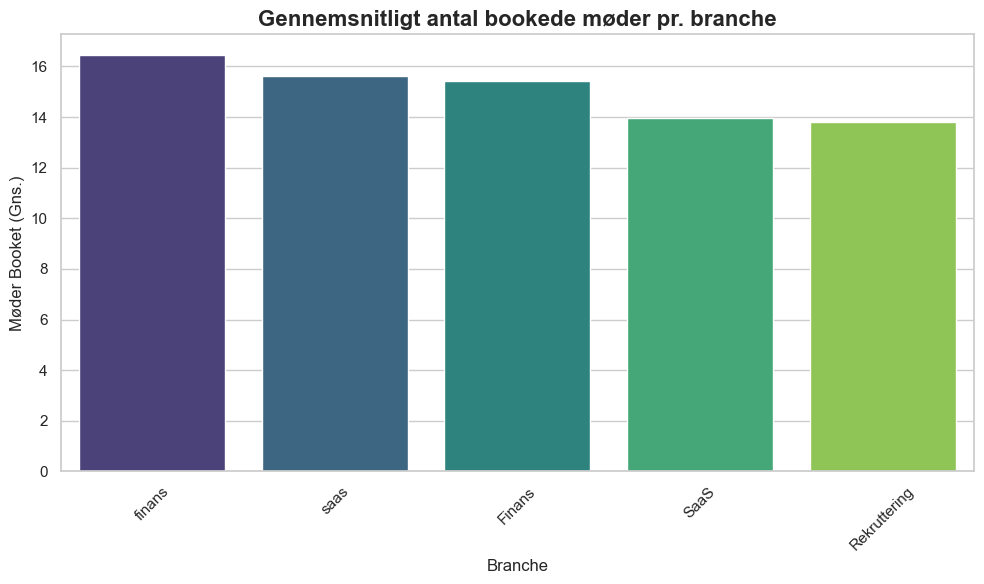

Gennemsnitligt antal bookede møder pr. branche:


,target_industry,meetings_booked
0,finans,16.437500
1,saas,15.619883
2,Finans,15.425806
3,SaaS,13.950980
4,Rekruttering,13.788235


In [24]:
# Grupperer data for at finde gennemsnittet af bookede møder for hver branche
industry_stats = df.groupby('target_industry')['meetings_booked'].mean().sort_values(ascending=False).reset_index()

# Plot, Møder booket pr. branche
plt.figure(figsize=(10, 6))
sns.barplot(data=industry_stats, x='target_industry', y='meetings_booked', palette='viridis')
plt.title('Gennemsnitligt antal bookede møder pr. branche', fontsize=16, fontweight='bold')
plt.xlabel('Branche', fontsize=12)
plt.ylabel('Møder Booket (Genemsnit:)', fontsize=12)
plt.xticks(rotation=45) # Roterer teksten, så de lange branchenavne er til at læse
plt.tight_layout()
plt.show()

# printer de rå tal ud for en god ordens skyld
print("Gennemsnitligt antal bookede møder pr. branche:")
display(industry_stats)

## 4. Hypotesetest: Er Deep Dive og Knowledge Base pengene værd? 

Brugere betaler 3x credits for "Deep Dive" leads og bruger tid på at uploade RAG-dokumenter til vores Knowledge Base. Men giver det overhovedet mening på bundlinjen? 

Jeg vil teste Hypotese 1 og 3 ved at kigge på konverteringsraterne. Jeg beregner den overordnede `booking_rate` (bookede møder divideret med sendte emails) og sammenligner Standard vs. Deep Dive kampagner. Til sidst smider vi et boxplot ind for at se spredningen 

,enrichment_mode,knowledge_base_active,booking_rate_pct,meetings_booked
0,Deep Dive,False,0.96,15.84
1,Deep Dive,True,0.98,15.28
2,Standard,False,0.93,12.31
3,Standard,True,1.01,15.96


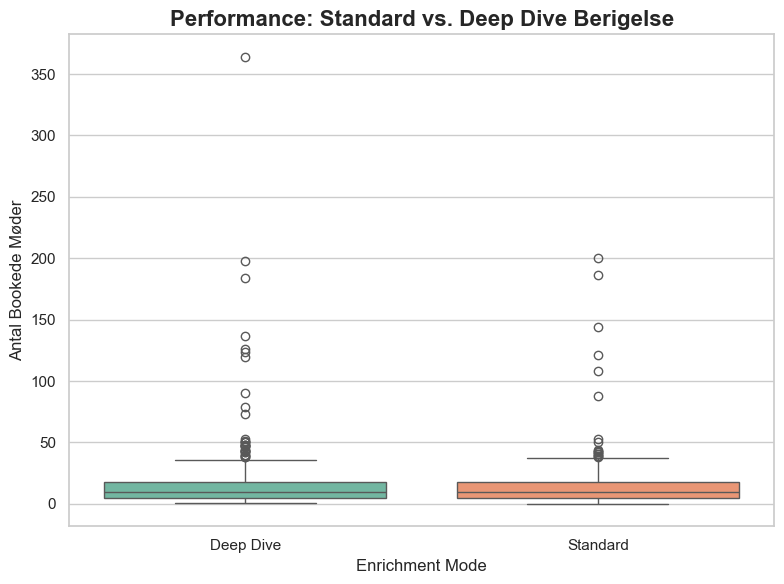


--- STATISTISK BEVIS ---
T-test P-værdi: nan
❌ P-værdien er over 0.05. Forskellen kan skyldes tilfældigheder.


In [23]:
from scipy.stats import ttest_ind

# Beregner den reelle konverteringsrate og lav det til procenter
df['booking_rate_pct'] = (df['meetings_booked'] / df['emails_sent']) * 100

# Aggreger data for at se forskellen mellem feature brugen
roi_analysis = df.groupby(['enrichment_mode', 'knowledge_base_active'])[['booking_rate_pct', 'meetings_booked']].mean().reset_index()
display(roi_analysis.round(2))

# Visualiser spredningen af bookede møder, Standard mod Deep Dive
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='enrichment_mode', y='meetings_booked', hue='enrichment_mode', palette='Set2', legend=False)
plt.title('Performance: Standard vs. Deep Dive Berigelse', fontsize=16, fontweight='bold')
plt.xlabel('Enrichment Mode', fontsize=12)
plt.ylabel('Antal Bookede Møder', fontsize=12)
plt.tight_layout()
plt.show()

# hypotesetest (P-værdi)
deep_dive_data = df[df['enrichment_mode'] == 'Deep Dive']['meetings_booked']
standard_data = df[df['enrichment_mode'] == 'Standard']['meetings_booked']

# Udfør independent T-test
t_stat, p_value = ttest_ind(deep_dive_data, standard_data)

print(f"\n STATISTISK BEVIS")
print(f"T-test P-værdi: {p_value:.5f}")
if p_value < 0.05:
    print("P-værdien er under 0.05. Vi forkaster Nul-hypotesen.")
    print("Konklusion: Der er en statistisk signifikant forskel på Deep Dive og Standard leads")
else:
    print("P-værdien er over 0.05. Forskellen kan skyldes tilfældigheder.")

## 5 Feature Correlation til at finde ud af hvad der vigtigst. 
Før vi fodrer vores Machine Learning model, skal vi bevise matematisk, hvilke variabler der hænger mest sammen med vores mål (`meetings_booked`). Vi bygger et Heatmap for at se korrelationen mellem vores data.

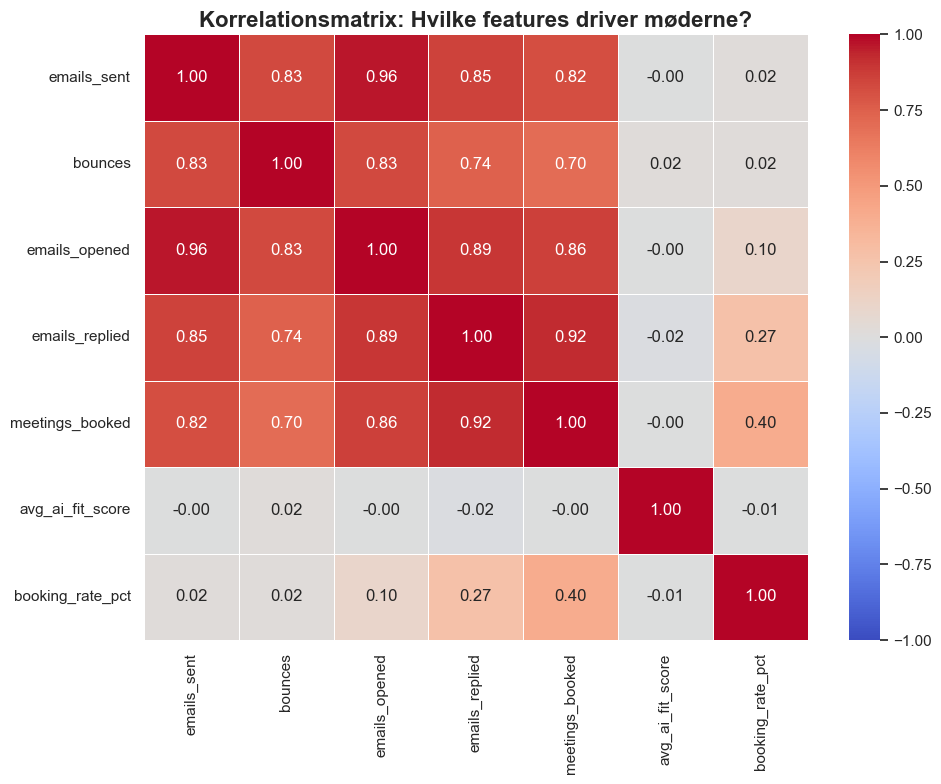

In [31]:
# Udregn booking_rate_pct, så vi kan se, hvad der korrelerer med den rene konvertering
df['booking_rate_pct'] = (df['meetings_booked'] / df['emails_sent']) * 100

# tager de numeriske kolonner til vores matrix
numeric_cols = df[['emails_sent', 'bounces', 'emails_opened', 'emails_replied', 'meetings_booked', 'avg_ai_fit_score', 'booking_rate_pct']]

# Udregner korrelationen
correlation_matrix = numeric_cols.corr()

# Plot vores Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korrelationsmatrix: Hvilke features gir flest møder?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Machine Learning Del 1: Supervised (Kan vi forudsige succes?) 

Her rykker vi ind i Stage 3. Jeg vil bygge en prædiktiv model, der kan forudsige, om en kampagne bliver en "Succes". Vi definerer her succes som mere end 3 bookede møder i én kampagne. 

Jeg bruger en **Random Forest Classifier** (Supervised Learning), som samler data fra flere beslutningstræer for at minimere fejl. Som "features" (det modellen gætter ud fra) fodrer jeg den med: 
- Antal sendte mails (`emails_sent`)
- Kampagnens AI fit score (`avg_ai_fit_score`)
- Om den brugte Deep Dive (konverteret til 1 eller 0).

Classification Report (Precision, Recall, F1)
              precision    recall  f1-score   support

           0       0.57      0.45      0.51        44
           1       0.85      0.90      0.88       156

    accuracy                           0.81       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.79      0.81      0.80       200



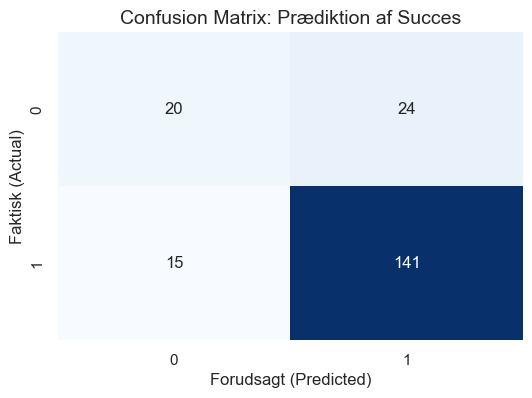

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Definer vores Target variabel "Succes" (1 = succes, 0 = fiasko)
df['is_success'] = (df['meetings_booked'] > 3).astype(int)

# computeren forstår ikke tekst, så vi gør så at "Deep Dive" bliver til 1, "Standard" bliver 0
df['is_deep_dive'] = (df['enrichment_mode'] == 'Deep Dive').astype(int)

# Vi sikrer lige at ai_fit_score altid er et tal, just in case
df['avg_ai_fit_score'] = pd.to_numeric(df['avg_ai_fit_score'], errors='coerce').fillna(50)

features = ['emails_sent', 'avg_ai_fit_score', 'is_deep_dive']
X = df[features]
y = df['is_success']

# Split data i Træning (80%) og Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Træner modellen med Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tester modellen på vores test-data
predictions = model.predict(X_test)

# Print de nøvendige metrics
print("Classification Report (Precision, Recall, F1)")
print(classification_report(y_test, predictions))

# Viser en Confusion Matrix med Seaborn for at gøre det lækkert at kigge på
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Prædiktion af Succes', fontsize=14)
plt.xlabel('Forudsagt (Predicted)')
plt.ylabel('Faktisk (Actual)')
plt.show()

## 7. Machine Learning Del 2: Unsupervised (Kundesegmentering) 

Til sidst kigger vi på Hypotese 4: Sender de dyre abonnementsbrugere flere emails? For at finde de "skjulte" mønstre i brugernes adfærd, laver vi en Unsupervised K-Means Clustering algoritme. 

Den grupperer kampagnerne i 3 naturlige clusters baseret på volumen (`emails_sent`) og kvalitet (`avg_ai_fit_score`). En lille note: Jeg bruger en `StandardScaler` først, for ellers vil `emails_sent` (som går op til 10.000) overdøve AI scoren, som kun går til 100, i algoritmens matematik.

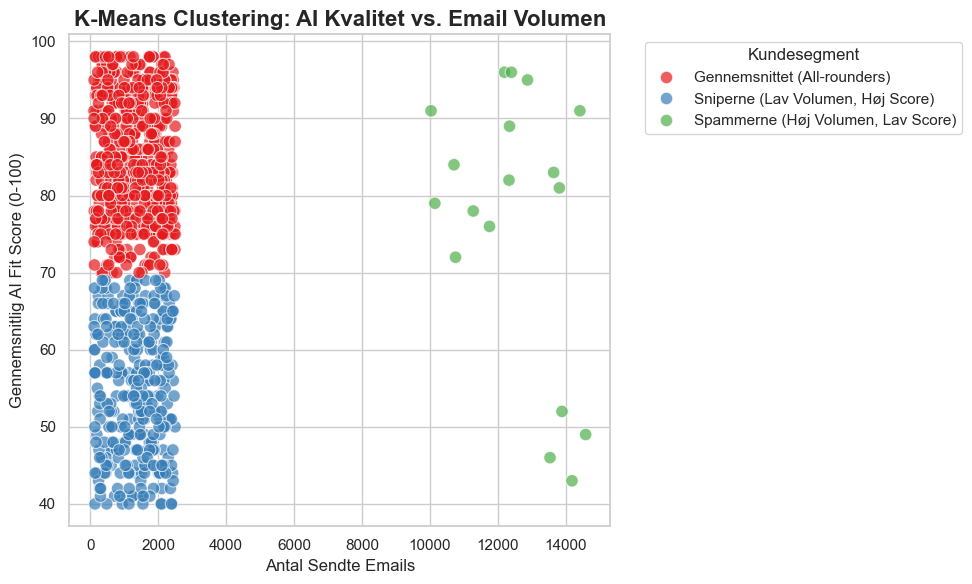

Sådan fordeler kampagnerne sig på de 3 kundesegmenter:
cluster_name
Gennemsnittet (All-rounders)          652
Sniperne (Lav Volumen, Høj Score)     330
Spammerne (Høj Volumen, Lav Score)     18
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import StandardScaler

# Vælger features til clustering
cluster_features = ['emails_sent', 'avg_ai_fit_score']
X_cluster = df[cluster_features]

# Skalere dataen, vigtigt for K-Means, så enhederne kan sammenlignes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Initialiserer og træn K-Means (3 kundesegmenter)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# navngive de fundne clusters ud fra forretningslogik
cluster_names = {0: 'Gennemsnittet (All-rounders)', 1: 'Spammerne (Høj Volumen, Lav Score)', 2: 'Sniperne (Lav Volumen, Høj Score)'}
df['cluster_name'] = df['cluster'].map(cluster_names)

# Visualiserer de 3 kundetyper i et scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='emails_sent', 
    y='avg_ai_fit_score', 
    hue='cluster_name', 
    palette='Set1', 
    s=80, 
    alpha=0.7
)
plt.title('K-Means Clustering: AI Kvalitet vs. Email Volumen', fontsize=16, fontweight='bold')
plt.xlabel('Antal Sendte Emails', fontsize=12)
plt.ylabel('Gennemsnitlig AI Fit Score (0-100)', fontsize=12)
plt.legend(title='Kundesegment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Sådan fordeler kampagnerne sig på de 3 kundesegmenter:")
print(df['cluster_name'].value_counts())